In [ ]:
### MLESS 2026

## Step 1 — Load data & filter to Cologne

Data: EEA Air Quality In-Situ Measurement Station Data (daily aggregate),
Data source: Zenodo DOI 10.5281/zenodo.14513586, CC-BY-4.0.

The full file has ~9.3M rows across all of Europe. We use PyArrow's predicate pushdown to read *only* the rows we need (Germany, Cologne bounding box) so we never load the whole file into memory.

In [3]:
import numpy as np
import pandas as pd
import pyarrow.dataset as ds

DATA_PATH = r"C:\Users\User\Desktop\MLESS_2026\airqualitymless.parquet"

In [5]:
COLOGNE_BBOX = dict(lon_min=6.75, lon_max=7.15, lat_min=50.80, lat_max=51.10)

dataset = ds.dataset(DATA_PATH, format="parquet")

flt = (
    (ds.field("Countrycode") == "DE")
    & (ds.field("Longitude") >= COLOGNE_BBOX["lon_min"])
    & (ds.field("Longitude") <= COLOGNE_BBOX["lon_max"])
    & (ds.field("Latitude")  >= COLOGNE_BBOX["lat_min"])
    & (ds.field("Latitude")  <= COLOGNE_BBOX["lat_max"])
)

df = dataset.to_table(filter=flt).to_pandas()
print(f"Loaded {len(df):,} Cologne-area rows")
df.head()

Loaded 16,646 Cologne-area rows


,Air.Quality.Station.EoI.Code,year,month,doy,NO2,O3_max8h,O3,PM10,PM10_90.41,PM2.5,...,cov.month.PM2.5,cov.day.PM2.5,cov.year.SO2,cov.month.SO2,cov.day.SO2,Countrycode,Station.Type,Station.Area,Longitude,Latitude
0,DENW053,2015.0,1.0,1.0,33.369409,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,DE,background,urban,6.8846,51.0193
1,DENW053,2015.0,1.0,2.0,19.081211,54.600875,43.820435,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,DE,background,urban,6.8846,51.0193
2,DENW053,2015.0,1.0,3.0,28.881636,48.466125,27.685783,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,DE,background,urban,6.8846,51.0193
3,DENW053,2015.0,1.0,5.0,49.077857,NaN,NaN,23.447826,23.447826,NaN,...,NaN,NaN,NaN,NaN,NaN,DE,background,urban,6.8846,51.0193
4,DENW053,2015.0,1.0,6.0,54.253348,NaN,NaN,23.357083,23.357083,NaN,...,NaN,NaN,NaN,NaN,NaN,DE,background,urban,6.8846,51.0193


## Step 2 — Exploring the stations to choose a target

The Cologne bounding box returned several stations. Before modeling we need to
pick ONE target station. To decide, we explore:
- which stations exist, and their type/area,
- how complete each pollutant's record is (coverage %),
- how long each record spans.

In [7]:
# How many stations, and what are they?
print("Number of stations in the Cologne box:",
      df["Air.Quality.Station.EoI.Code"].nunique())

df[["Air.Quality.Station.EoI.Code", "Station.Type", "Station.Area"]].drop_duplicates()

Number of stations in the Cologne box: 7


,Air.Quality.Station.EoI.Code,Station.Type,Station.Area
0,DENW053,background,urban
1659,DENW058,industrial,suburban
3057,DENW059,background,suburban
5262,DENW079,background,suburban
7345,DENW211,traffic,urban
10510,DENW212,traffic,urban
13630,DENW355,traffic,urban


### 2.1 How many stations are in the Cologne area?

First I check how many distinct monitoring stations fall inside the bounding box,
and what kind of stations they are (traffic / background / industrial, and
urban / suburban). This tells me what I have to choose from.

In [9]:
STATION_COL = "Air.Quality.Station.EoI.Code"

def station_coverage(df):
    pollutants = ["NO2", "PM2.5", "PM10", "O3"]
    def _stats(g):
        out = {
            "Type": g["Station.Type"].iloc[0],
            "Area": g["Station.Area"].iloc[0],
            "n_days": len(g),
            "year_min": int(g["year"].min()),
            "year_max": int(g["year"].max()),
        }
        for p in pollutants:
            out[f"{p}_%"] = round(g[p].notna().mean() * 100, 1)
        return pd.Series(out)
    return df.groupby(STATION_COL).apply(_stats).reset_index()

coverage = station_coverage(df).sort_values("NO2_%", ascending=False)
coverage

,Air.Quality.Station.EoI.Code,Type,Area,n_days,year_min,year_max,NO2_%,PM2.5_%,PM10_%,O3_%
0,DENW053,background,urban,1659,2015,2023,100.0,0.0,61.7,60.2
1,DENW058,industrial,suburban,1398,2015,2023,100.0,6.9,76.4,71.2
2,DENW059,background,suburban,2205,2015,2023,100.0,0.0,66.7,57.3
3,DENW079,background,suburban,2083,2015,2023,100.0,4.9,44.6,58.8
4,DENW211,traffic,urban,3165,2015,2023,100.0,14.3,76.6,0.0
5,DENW212,traffic,urban,3120,2015,2023,100.0,55.2,63.2,0.0
6,DENW355,traffic,urban,3016,2015,2023,100.0,27.6,49.4,0.0


### 2.2 How complete is each station's data?

A station is only useful if it actually has data. Here I compute, for every
station, the percentage of days that have a valid measurement for each pollutant
(NO2, PM2.5, PM10, O3), plus how many days it covers and over which years.
The `_stats` helper is applied to each station group and returns summarry.

In [11]:
STATION_COL = "Air.Quality.Station.EoI.Code"

def station_coverage(df):
    pollutants = ["NO2", "PM2.5", "PM10", "O3"]
    def _stats(g):
        out = {
            "Type": g["Station.Type"].iloc[0],
            "Area": g["Station.Area"].iloc[0],
            "n_days": len(g),
            "year_min": int(g["year"].min()),
            "year_max": int(g["year"].max()),
        }
        for p in pollutants:
            out[f"{p}_%"] = round(g[p].notna().mean() * 100, 1)
        return pd.Series(out)
    return df.groupby(STATION_COL).apply(_stats).reset_index()

coverage = station_coverage(df).sort_values("NO2_%", ascending=False)
coverage

,Air.Quality.Station.EoI.Code,Type,Area,n_days,year_min,year_max,NO2_%,PM2.5_%,PM10_%,O3_%
0,DENW053,background,urban,1659,2015,2023,100.0,0.0,61.7,60.2
1,DENW058,industrial,suburban,1398,2015,2023,100.0,6.9,76.4,71.2
2,DENW059,background,suburban,2205,2015,2023,100.0,0.0,66.7,57.3
3,DENW079,background,suburban,2083,2015,2023,100.0,4.9,44.6,58.8
4,DENW211,traffic,urban,3165,2015,2023,100.0,14.3,76.6,0.0
5,DENW212,traffic,urban,3120,2015,2023,100.0,55.2,63.2,0.0
6,DENW355,traffic,urban,3016,2015,2023,100.0,27.6,49.4,0.0


### 2.3 Visualizing coverage

The table is easier to compare as a bar chart. Each group of bars is one station,
showing coverage for the four pollutants side by side. The dashed line marks 100%.
This makes it obvious which stations have complete NO2 data and decent secondary
pollutants.

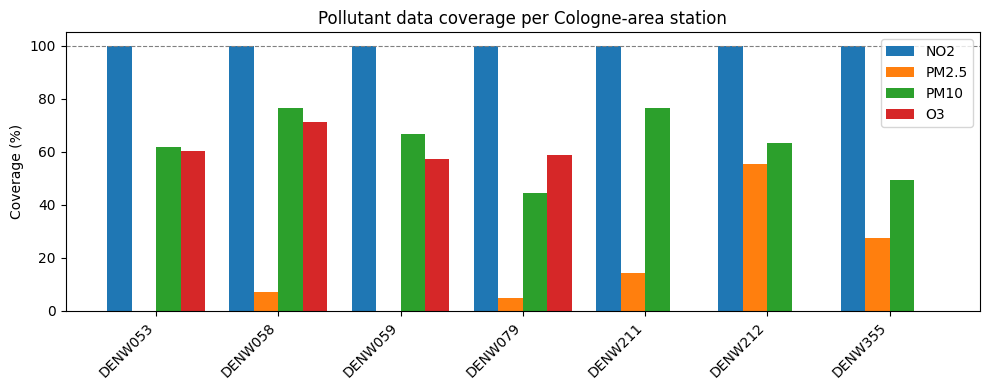

In [15]:
import matplotlib.pyplot as plt
import numpy as np

pollutants = ["NO2_%", "PM2.5_%", "PM10_%", "O3_%"]
stations = coverage[STATION_COL].tolist()
x = np.arange(len(stations))
width = 0.2

fig, ax = plt.subplots(figsize=(10, 4))
for i, p in enumerate(pollutants):
    ax.bar(x + i * width, coverage[p], width, label=p.replace("_%", ""))

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(stations, rotation=45, ha="right")
ax.set_ylabel("Coverage (%)")
ax.set_title("Pollutant data coverage per Cologne-area station")
ax.axhline(100, color="grey", ls="--", lw=0.8)
ax.legend()
plt.tight_layout()
plt.show()

## Step 3 — Rebuild the daily time series for DENW212

The daily file doesn't store an actual date — it stores `year` and `doy`
(day-of-year). To do time-series forecasting I need a real calendar date for
each row. I reconstruct it as: January 1st of `year`, plus (`doy` - 1) days.

I also reduce the data to just the station and columns I need:
NO2 (target) and PM10 (secondary input for the ablation later).

In [19]:
TARGET_STATION = "DENW212"
TARGET_POLLUTANT = "NO2"
print(f"Selected station: {TARGET_STATION}, target pollutant: {TARGET_POLLUTANT}")

Selected station: DENW212, target pollutant: NO2


In [21]:
# Keep only the chosen station
station = df[df["Air.Quality.Station.EoI.Code"] == TARGET_STATION].copy()

# Rebuild a real calendar date from year + day-of-year
station["date"] = (
    pd.to_datetime(station["year"].astype(int).astype(str), format="%Y")
    + pd.to_timedelta(station["doy"].astype(int) - 1, unit="D")
)

# Sort by date, index by date, keep only the columns we need
station = station.sort_values("date").set_index("date")
series = station[["NO2", "PM10"]]

print(f"Station {TARGET_STATION}: {series.index.min().date()} to {series.index.max().date()}")
print(f"Number of rows (days with data): {len(series)}")
series.head()

Station DENW212: 2015-01-01 to 2023-12-30
Number of rows (days with data): 3120


,NO2,PM10
date,,
2015-01-01,36.421273,124.291636
2015-01-02,48.140913,18.920636
2015-01-03,47.307087,19.705318
2015-01-04,49.474435,26.695000
2015-01-05,67.193435,26.115167


In [23]:
# Full continuous daily range from first to last date
full_range = pd.date_range(series.index.min(), series.index.max(), freq="D")

n_expected = len(full_range)
n_actual = len(series)
missing_dates = full_range.difference(series.index)

print(f"Expected days (full range): {n_expected}")
print(f"Actual days present:        {n_actual}")
print(f"Missing days:               {len(missing_dates)}  ({len(missing_dates)/n_expected*100:.1f}%)")

Expected days (full range): 3286
Actual days present:        3120
Missing days:               166  (5.1%)


In [25]:
print("Null counts in the rows we have:")
print(series.isna().sum())

print(f"\nNO2 summary (ug/m3):")
print(series["NO2"].describe())

Null counts in the rows we have:
NO2        0
PM10    1149
dtype: int64

NO2 summary (ug/m3):
count    3120.000000
mean       37.521034
std        11.754286
min        12.492850
25%        28.751707
50%        36.435293
75%        45.163500
max        86.977043
Name: NO2, dtype: float64


### What this means

- **NO2 has zero missing values** → the forecast target is clean, no imputation needed.
- **PM10 has 1,149 missing values** (~37% of days) → usable as a secondary input,
  but the multivariate experiment will have fewer samples than the univariate one.
  I'll keep the comparison fair by evaluating on the same test period.
- NO2 averages 37.5 µg/m³, close to the EU annual limit of 40 µg/m³, which
  motivates forecasting it. Values range 12–87 µg/m³ with no impossible readings.

## Step 4 — Build supervised windows (gap-aware)

A neural network needs (input, target) pairs, not a raw series. I use a sliding
window: the previous 7 days of features predict the NO2 value on the 8th day.

Because ~5% of calendar days are missing, the windowing is **gap-aware**: a
window is only kept if all its days (7 input days + the target day) are strictly
consecutive calendar dates. This stops the model from learning a "next day" that
is really several days later across a gap.

In [27]:
def make_windows(series, target="NO2", features=None, window=7, horizon=1):
    """
    Turn a date-indexed DataFrame into (X, y) windows.
    Only keeps windows where all days are strictly consecutive (gap-aware).

    Returns:
        X: array, shape (n_samples, window, n_features)
        y: array, shape (n_samples,)
        dates: array of the target date for each sample
    """
    if features is None:
        features = [target]

    sub = series[features]
    values = sub.values
    dates = sub.index.values
    target_idx = features.index(target)

    X_list, y_list, d_list = [], [], []
    span = window + horizon
    one_day = np.timedelta64(1, "D")

    for i in range(len(sub) - span + 1):
        block_dates = dates[i : i + span]
        if np.all(np.diff(block_dates) == one_day):          # no gaps
            block_vals = values[i : i + span]
            if not np.isnan(block_vals).any():               # no missing values
                X_list.append(values[i : i + window])
                y_list.append(values[i + window + horizon - 1, target_idx])
                d_list.append(dates[i + window + horizon - 1])

    X = np.array(X_list, dtype=np.float32)
    y = np.array(y_list, dtype=np.float32)
    d = np.array(d_list)
    return X, y, d

## Step 4 — Build supervised windows (gap-aware)

A neural network needs (input, target) pairs, not a raw series. I use a sliding
window: the previous 7 days of features predict the NO2 value on the 8th day.

Gap-aware: a window is only kept if all its days (7 input + 1 target) are
strictly consecutive calendar dates, so the model never learns across a hole.

In [29]:
def make_windows(series, target="NO2", features=None, window=7, horizon=1):
    """
    Turn a date-indexed DataFrame into (X, y) windows.
    Only keeps windows where all days are strictly consecutive (gap-aware).

    Returns:
        X: array, shape (n_samples, window, n_features)
        y: array, shape (n_samples,)
        dates: array of the target date for each sample
    """
    if features is None:
        features = [target]

    sub = series[features]
    values = sub.values
    dates = sub.index.values
    target_idx = features.index(target)

    X_list, y_list, d_list = [], [], []
    span = window + horizon
    one_day = np.timedelta64(1, "D")

    for i in range(len(sub) - span + 1):
        block_dates = dates[i : i + span]
        if np.all(np.diff(block_dates) == one_day):          # no gaps
            block_vals = values[i : i + span]
            if not np.isnan(block_vals).any():               # no missing values
                X_list.append(values[i : i + window])
                y_list.append(values[i + window + horizon - 1, target_idx])
                d_list.append(dates[i + window + horizon - 1])

    X = np.array(X_list, dtype=np.float32)
    y = np.array(y_list, dtype=np.float32)
    d = np.array(d_list)
    return X, y, d

### 4.1 Build univariate windows (NO2 only)

Now I apply the windowing recipe to build the univariate dataset:
7 days of NO2 → the next day's NO2.
Since NO2 has no missing values, only the day-gaps reduce the sample count.

In [31]:
WINDOW = 7
HORIZON = 1

X_uni, y_uni, dates_uni = make_windows(
    series, target="NO2", features=["NO2"], window=WINDOW, horizon=HORIZON
)

print("Univariate dataset:")
print(f"  X shape: {X_uni.shape}   (samples, window_days, features)")
print(f"  y shape: {y_uni.shape}")
print(f"  first target date: {dates_uni.min()}")
print(f"  last target date:  {dates_uni.max()}")

Univariate dataset:
  X shape: (2474, 7, 1)   (samples, window_days, features)
  y shape: (2474,)
  first target date: 2015-01-08T00:00:00.000000000
  last target date:  2023-12-20T00:00:00.000000000


### 4.2 Build multivariate windows (NO2 + PM10)

Now the multivariate dataset: 7 days of NO2 AND PM10 → next day's NO2.
Because PM10 has ~1,149 missing values, any window containing a missing PM10
value is dropped. So this dataset is smaller than the univariate one — an
important point for keeping the ablation comparison fair later.

In [33]:
X_multi, y_multi, dates_multi = make_windows(
    series, target="NO2", features=["NO2", "PM10"], window=WINDOW, horizon=HORIZON
)

print("Multivariate dataset:")
print(f"  X shape: {X_multi.shape}   (samples, window_days, features)")
print(f"  y shape: {y_multi.shape}")

print(f"\nUnivariate samples:   {len(y_uni)}")
print(f"Multivariate samples: {len(y_multi)}")
print(f"Dropped due to PM10 gaps: {len(y_uni) - len(y_multi)}")

Multivariate dataset:
  X shape: (486, 7, 2)   (samples, window_days, features)
  y shape: (486,)

Univariate samples:   2474
Multivariate samples: 486
Dropped due to PM10 gaps: 1988


### 4.3 Handle PM10 gaps with forward fill

Requiring PM10 dropped 80% of windows (2474 → 486), because scattered PM10 gaps
poison every window they touch. To keep the data usable AND make the later
ablation fair, I forward-fill PM10: each missing value is replaced by the most
recent known value.

Forward fill is *causal* — it only uses past values, so it introduces no future
information leakage. Caveat: long PM10 gaps get a repeated (stale) value, which
partly weakens the PM10 signal. This is noted as a limitation.

In [35]:
# Copy so we keep the original series intact for comparison
series_ffill = series.copy()

print("PM10 missing values BEFORE forward fill:", series_ffill["PM10"].isna().sum())

# Forward fill PM10 (carry last known value forward)
series_ffill["PM10"] = series_ffill["PM10"].ffill()

# If the very first rows are still NaN (nothing earlier to fill from),
# back-fill just those leading values
series_ffill["PM10"] = series_ffill["PM10"].bfill()

print("PM10 missing values AFTER forward fill: ", series_ffill["PM10"].isna().sum())
series_ffill.head()

PM10 missing values BEFORE forward fill: 1149
PM10 missing values AFTER forward fill:  0


,NO2,PM10
date,,
2015-01-01,36.421273,124.291636
2015-01-02,48.140913,18.920636
2015-01-03,47.307087,19.705318
2015-01-04,49.474435,26.695000
2015-01-05,67.193435,26.115167


### 4.4 Rebuild multivariate windows on the forward-filled series

Now that PM10 has no missing values, I rebuild the multivariate windows using
`series_ffill`. This time only the day-gaps reduce the count (not PM10 nulls),
so the sample count should match the univariate dataset — giving a fair,
like-for-like ablation.

In [37]:
X_multi, y_multi, dates_multi = make_windows(
    series_ffill, target="NO2", features=["NO2", "PM10"], window=WINDOW, horizon=HORIZON
)

print("Multivariate dataset (after forward fill):")
print(f"  X shape: {X_multi.shape}   (samples, window_days, features)")
print(f"  y shape: {y_multi.shape}")

print(f"\nUnivariate samples:   {len(y_uni)}")
print(f"Multivariate samples: {len(y_multi)}")
print(f"Difference: {len(y_uni) - len(y_multi)}")

Multivariate dataset (after forward fill):
  X shape: (2474, 7, 2)   (samples, window_days, features)
  y shape: (2474,)

Univariate samples:   2474
Multivariate samples: 2474
Difference: 0


## Step 5 — Chronological train/test split

For forecasting, the split MUST respect time: train on the past, test on the
future. A random split would leak future information into training and give
falsely optimistic results.

Split: train = targets before 2022 (2015–2021), test = targets from 2022 onward
(2022–2023). This is roughly an 80/20 split. I apply the SAME split to both the
univariate and multivariate datasets so they are evaluated on identical dates.

In [39]:
SPLIT_YEAR = 2022

def chronological_split(X, y, dates, split_year=SPLIT_YEAR):
    # extract the year from each target date
    years = dates.astype("datetime64[Y]").astype(int) + 1970
    train_mask = years < split_year
    test_mask = ~train_mask
    return (
        X[train_mask], y[train_mask], dates[train_mask],
        X[test_mask],  y[test_mask],  dates[test_mask],
    )

# Univariate split
Xtr_uni, ytr_uni, dtr_uni, Xte_uni, yte_uni, dte_uni = chronological_split(
    X_uni, y_uni, dates_uni
)

# Multivariate split (same cutoff, same dates)
Xtr_multi, ytr_multi, dtr_multi, Xte_multi, yte_multi, dte_multi = chronological_split(
    X_multi, y_multi, dates_multi
)

print("Univariate  -> train:", len(ytr_uni), " test:", len(yte_uni))
print("Multivariate-> train:", len(ytr_multi), " test:", len(yte_multi))
print(f"\nTrain dates: {dtr_uni.min()} to {dtr_uni.max()}")
print(f"Test dates:  {dte_uni.min()} to {dte_uni.max()}")

Univariate  -> train: 2058  test: 416
Multivariate-> train: 2058  test: 416

Train dates: 2015-01-08T00:00:00.000000000 to 2021-12-31T00:00:00.000000000
Test dates:  2022-01-01T00:00:00.000000000 to 2023-12-20T00:00:00.000000000


## Step 6 — Standardize the features

Neural networks train better when inputs are centered at 0 with spread 1.
I standardize each feature using the formula (value − mean) / std.

Critical: the mean and std are computed from the TRAINING data only, then applied
to both train and test. Using test data to compute them would leak future
information. I also keep the target's mean/std so predictions can be converted
back to real ug/m3 later.

In [41]:
def standardize(X_train, X_test):
    """
    Standardize features using TRAIN statistics only.
    X shape: (samples, window_days, features)
    Returns scaled train, scaled test, and the per-feature (mean, std).
    """
    # Flatten across samples and days to compute per-feature stats on train
    flat = X_train.reshape(-1, X_train.shape[-1])
    mean = flat.mean(axis=0)
    std = flat.std(axis=0)
    std[std == 0] = 1.0  # safety: avoid divide-by-zero

    X_train_s = (X_train - mean) / std
    X_test_s  = (X_test  - mean) / std
    return X_train_s.astype("float32"), X_test_s.astype("float32"), mean, std


# --- Univariate ---
Xtr_uni_s, Xte_uni_s, mean_uni, std_uni = standardize(Xtr_uni, Xte_uni)

# --- Multivariate ---
Xtr_multi_s, Xte_multi_s, mean_multi, std_multi = standardize(Xtr_multi, Xte_multi)

# NO2 is feature index 0 in both -> save its mean/std to un-scale predictions later
no2_mean = mean_uni[0]
no2_std  = std_uni[0]

print("Univariate feature mean/std (NO2):      ", mean_uni.round(2), std_uni.round(2))
print("Multivariate feature mean/std (NO2,PM10):", mean_multi.round(2), std_multi.round(2))
print(f"\nSaved for un-scaling predictions -> NO2 mean: {no2_mean:.2f}, std: {no2_std:.2f}")

Univariate feature mean/std (NO2):       [40.27] [11.58]
Multivariate feature mean/std (NO2,PM10): [40.27 21.78] [11.58  8.99]

Saved for un-scaling predictions -> NO2 mean: 40.27, std: 11.58


## Step 7 — Persistence baseline

Before any neural network, I build the simplest possible forecaster as a yardstick:
persistence, which predicts "tomorrow = today". For each test window, its
prediction for the target day is simply the NO2 value of the last input day
(day 7 of the 7-day window).

Every real model must beat this baseline to justify its complexity. Persistence
is a fair yardstick because daily NO2 changes slowly, so "same as yesterday" is
often roughly right.

In [43]:
# Persistence uses the raw (un-scaled) test windows so it's in real ug/m3.
# The prediction = NO2 on the last input day of each window.
# Xte_uni shape is (samples, 7 days, 1 feature); NO2 is feature 0.

persistence_pred = Xte_uni[:, -1, 0]   # last day, NO2 feature, for every test window
y_true = yte_uni                       # the real day-8 NO2 values (already in ug/m3)

print("Example — first 5 test windows:")
for i in range(5):
    print(f"  last input day (day 7) = {persistence_pred[i]:.1f}  ->  "
          f"prediction = {persistence_pred[i]:.1f},  actual day 8 = {y_true[i]:.1f}")

Example — first 5 test windows:
  last input day (day 7) = 24.4  ->  prediction = 24.4,  actual day 8 = 25.4
  last input day (day 7) = 28.0  ->  prediction = 28.0,  actual day 8 = 32.5
  last input day (day 7) = 32.5  ->  prediction = 32.5,  actual day 8 = 39.7
  last input day (day 7) = 39.7  ->  prediction = 39.7,  actual day 8 = 32.5
  last input day (day 7) = 32.5  ->  prediction = 32.5,  actual day 8 = 25.1


## Step 8 — Evaluate the persistence baseline (RMSE & MAE)

I measure the baseline's error across all 416 test windows using two metrics:

- MAE (Mean Absolute Error): average of |prediction − actual|. Directly readable
  as "on average, how many ug/m3 off is the forecast?"
- RMSE (Root Mean Squared Error): squares errors before averaging, so it
  penalizes large misses (e.g. pollution spikes) more heavily than MAE.

Reporting both gives a fuller picture: MAE for typical error, RMSE for
sensitivity to big errors. These baseline numbers are the reference every
neural network must beat.

In [45]:
import numpy as np

def compute_metrics(y_true, y_pred):
    """Return MAE and RMSE (both in ug/m3)."""
    errors = y_pred - y_true
    mae = np.mean(np.abs(errors))
    rmse = np.sqrt(np.mean(errors ** 2))
    return mae, rmse

# Persistence predictions vs actual (both already in real ug/m3)
mae_persist, rmse_persist = compute_metrics(y_true, persistence_pred)

print("Persistence baseline (test set, 2022-2023):")
print(f"  MAE  = {mae_persist:.2f} ug/m3")
print(f"  RMSE = {rmse_persist:.2f} ug/m3")

# store results so we can compare all models at the end
results = {}
results["Persistence"] = {"MAE": mae_persist, "RMSE": rmse_persist}
results

Persistence baseline (test set, 2022-2023):
  MAE  = 6.22 ug/m3
  RMSE = 7.84 ug/m3


{'Persistence': {'MAE': 6.219804, 'RMSE': 7.8421054}}

In [47]:
try:
    import torch
    print("PyTorch is installed. Version:", torch.__version__)
    print("CUDA (GPU) available:", torch.cuda.is_available())
except ImportError:
    print("PyTorch is NOT installed.")

PyTorch is installed. Version: 2.12.0+cpu
CUDA (GPU) available: False


## Step 9 — Build the FFN (feed-forward network)

The FFN takes the 7-day window, flattens it into a flat list of numbers, and
passes it through two dense ("fully connected") layers to output a single number:
the predicted next-day NO2.

- Input: 7 days × n_features (7 for univariate, 14 for multivariate)
- Hidden layer: 32 neurons with a ReLU activation (lets it learn non-linear patterns)
- Output: 1 number (the prediction)

It has no notion of time order — it learns a weighted mapping from the flattened
inputs to the target.

In [49]:
import torch
import torch.nn as nn

# Reproducibility: fixes the random starting weights so results are repeatable
torch.manual_seed(42)

class FFN(nn.Module):
    def __init__(self, window, n_features, hidden=32):
        super().__init__()
        input_size = window * n_features        # flatten 7 days x features
        self.net = nn.Sequential(
            nn.Flatten(),                       # (batch, 7, feat) -> (batch, 7*feat)
            nn.Linear(input_size, hidden),      # dense layer
            nn.ReLU(),                          # non-linearity
            nn.Linear(hidden, 1),               # output one number
        )

    def forward(self, x):
        return self.net(x).squeeze(-1)          # shape (batch,) not (batch,1)

# Quick sanity check: build a univariate FFN and pass one fake batch through it
test_model = FFN(window=7, n_features=1)
dummy = torch.randn(4, 7, 1)                     # 4 fake windows
out = test_model(dummy)
print("Model built. Output shape for 4 inputs:", out.shape)   # expect (4,)
print(test_model)

Model built. Output shape for 4 inputs: torch.Size([4])
FFN(
  (net): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=7, out_features=32, bias=True)
    (2): ReLU()
    (3): Linear(in_features=32, out_features=1, bias=True)
  )
)


## Step 9b — Train the FFN (univariate: NO2 only)

Training repeats over many epochs. Each epoch: the model makes predictions,
we measure the error (MSE loss), PyTorch computes how to adjust the weights,
and the optimizer nudges them to reduce the error.

I train on the STANDARDIZED univariate training data. Predictions are later
un-scaled back to ug/m3 for interpretable metrics.

In [51]:
# --- Convert numpy arrays to PyTorch tensors ---
Xtr = torch.tensor(Xtr_uni_s)                     # standardized train inputs
ytr = torch.tensor((ytr_uni - no2_mean) / no2_std)  # standardize the targets too
Xte = torch.tensor(Xte_uni_s)                     # standardized test inputs

# --- Build a fresh model, loss, optimizer ---
torch.manual_seed(42)
model_ffn = FFN(window=7, n_features=1, hidden=32)
loss_fn = nn.MSELoss()
optimizer = torch.optim.Adam(model_ffn.parameters(), lr=0.01)

# --- Training loop ---
EPOCHS = 100
for epoch in range(EPOCHS):
    model_ffn.train()
    optimizer.zero_grad()          # reset gradients from last step
    preds = model_ffn(Xtr)         # forward: predictions on train
    loss = loss_fn(preds, ytr)     # measure error
    loss.backward()                # backward: compute how to adjust weights
    optimizer.step()               # update the weights

    if (epoch + 1) % 20 == 0:
        print(f"Epoch {epoch+1:3d}/{EPOCHS}  train loss (MSE, scaled): {loss.item():.4f}")

print("\nTraining done.")

Epoch  20/100  train loss (MSE, scaled): 0.6381
Epoch  40/100  train loss (MSE, scaled): 0.5987
Epoch  60/100  train loss (MSE, scaled): 0.5851
Epoch  80/100  train loss (MSE, scaled): 0.5780
Epoch 100/100  train loss (MSE, scaled): 0.5721

Training done.


## Step 9c — Evaluate the FFN on the test set

I run the trained FFN on the test data (2022–2023, never seen in training).
The model outputs standardized numbers, so I reverse the standardization
(real = standardized × std + mean) to get predictions back in ug/m3, then
compute MAE and RMSE and compare against the persistence baseline.

In [53]:
model_ffn.eval()                       # switch to evaluation mode
with torch.no_grad():                  # no training here, just predicting
    preds_scaled = model_ffn(Xte)      # predictions on test (standardized)

# Un-scale predictions back to ug/m3
preds_ffn = preds_scaled.numpy() * no2_std + no2_mean

# True values are already in ug/m3
mae_ffn, rmse_ffn = compute_metrics(yte_uni, preds_ffn)

print("FFN (univariate, NO2 only) — test set:")
print(f"  MAE  = {mae_ffn:.2f} ug/m3")
print(f"  RMSE = {rmse_ffn:.2f} ug/m3")

print("\nvs Persistence baseline:")
print(f"  MAE  = {mae_persist:.2f} ug/m3")
print(f"  RMSE = {rmse_persist:.2f} ug/m3")

# store for the final comparison table
results["FFN (uni)"] = {"MAE": mae_ffn, "RMSE": rmse_ffn}
results

FFN (univariate, NO2 only) — test set:
  MAE  = 5.73 ug/m3
  RMSE = 7.14 ug/m3

vs Persistence baseline:
  MAE  = 6.22 ug/m3
  RMSE = 7.84 ug/m3


{'Persistence': {'MAE': 6.219804, 'RMSE': 7.8421054},
 'FFN (uni)': {'MAE': 5.7341433, 'RMSE': 7.1379676}}

# FFN beats the baseline — a real, clean result:

MAE: 5.73 vs 6.22 → ~ 8% better than persistence / Baseline
RMSE: 7.14 vs 7.84 → ~ 9% better than persistence / Baseline

## Step 10 — Build the LSTM

Unlike the FFN, the LSTM reads the 7 days one at a time, in order, keeping a
running "memory" of what it has seen. After processing all 7 days, it uses its
final memory state to output the next-day NO2 prediction.

- Input: 7 days × n_features, fed sequentially
- LSTM layer: 32 hidden units (the size of its memory)
- Output: 1 number (the prediction), from the last time step

In [55]:
class LSTMModel(nn.Module):
    def __init__(self, n_features, hidden=32):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=n_features,   # how many features per day
            hidden_size=hidden,      # size of the memory
            batch_first=True,        # input shape is (batch, days, features)
        )
        self.fc = nn.Linear(hidden, 1)   # turn final memory into one number

    def forward(self, x):
        out, (h_n, c_n) = self.lstm(x)   # process the sequence
        last = out[:, -1, :]             # take the output at the LAST day
        return self.fc(last).squeeze(-1) # -> one prediction per window

# Sanity check with a fake univariate batch
torch.manual_seed(42)
test_lstm = LSTMModel(n_features=1)
dummy = torch.randn(4, 7, 1)
out = test_lstm(dummy)
print("LSTM built. Output shape for 4 inputs:", out.shape)   # expect (4,)
print(test_lstm)

LSTM built. Output shape for 4 inputs: torch.Size([4])
LSTMModel(
  (lstm): LSTM(1, 32, batch_first=True)
  (fc): Linear(in_features=32, out_features=1, bias=True)
)


## Step 10b — Train and evaluate the LSTM (univariate)

Same training loop as the FFN (MSE loss, Adam optimizer, 100 epochs), on the
same standardized univariate data. Only the model architecture differs. Then I
evaluate on the test set, un-scale predictions to ug/m3, and compare against
the FFN and persistence.

In [57]:
# --- Fresh LSTM, loss, optimizer ---
torch.manual_seed(42)
model_lstm = LSTMModel(n_features=1, hidden=32)
loss_fn = nn.MSELoss()
optimizer = torch.optim.Adam(model_lstm.parameters(), lr=0.01)

# --- Train (same loop as FFN) ---
EPOCHS = 100
for epoch in range(EPOCHS):
    model_lstm.train()
    optimizer.zero_grad()
    preds = model_lstm(Xtr)          # Xtr = standardized univariate train inputs
    loss = loss_fn(preds, ytr)       # ytr = standardized train targets
    loss.backward()
    optimizer.step()
    if (epoch + 1) % 20 == 0:
        print(f"Epoch {epoch+1:3d}/{EPOCHS}  train loss: {loss.item():.4f}")

# --- Evaluate on test set ---
model_lstm.eval()
with torch.no_grad():
    preds_scaled = model_lstm(Xte)   # Xte = standardized univariate test inputs

preds_lstm = preds_scaled.numpy() * no2_std + no2_mean
mae_lstm, rmse_lstm = compute_metrics(yte_uni, preds_lstm)

results["LSTM (uni)"] = {"MAE": mae_lstm, "RMSE": rmse_lstm}

print("\n--- Comparison so far ---")
for name, m in results.items():
    print(f"  {name:14s}  MAE={m['MAE']:.2f}  RMSE={m['RMSE']:.2f}")

Epoch  20/100  train loss: 0.6740
Epoch  40/100  train loss: 0.6122
Epoch  60/100  train loss: 0.6023
Epoch  80/100  train loss: 0.5986
Epoch 100/100  train loss: 0.5956

--- Comparison so far ---
  Persistence     MAE=6.22  RMSE=7.84
  FFN (uni)       MAE=5.73  RMSE=7.14
  LSTM (uni)      MAE=5.85  RMSE=7.23


## Reasons why FFN is performing better than LSTM:

1. 7 days is a very short sequence. The LSTM's advantage (modeling long temporal dependencies, trends, memory) needs longer sequences to pay off. With only 7 steps, there's little "order structure" to exploit that the FFN can't already capture through its per-slot weights.
2. NO₂ is dominated by "recent value." Tomorrow ≈ today is most of the signal. The FFN captures that easily (heavy weight on the last slot). The LSTM's extra machinery is solving a harder problem than the data actually requires.
3. The LSTM has more parameters and is harder to train on limited data. With only 2,058 training samples, the simpler FFN generalizes at least as well, a classic "simpler model wins on small data" outcome.
4. Notice the LSTM's training loss was slightly higher too (0.596 vs FFN's 0.572) — it didn't even fit the training data better. So it's not overfitting; the LSTM just didn't find a better solution here.

## Step 10c — Extra experiment: does window length change the FFN-vs-LSTM result?

Our hypothesis for why the LSTM didn't beat the FFN was "7 days is too short a
sequence for the LSTM's temporal modeling to help." I test this directly by
re-running the whole pipeline for several window lengths (7, 14, 30, 60 days).

If the hypothesis is right, the LSTM should catch up to (or overtake) the FFN as
the window grows.

In [59]:
def run_experiment(window, epochs=100, seed=42):
    """Build windows, split, scale, train FFN + LSTM, return metrics — for a given window size."""
    # 1. windows (univariate, NO2 only)
    X, y, d = make_windows(series, target="NO2", features=["NO2"], window=window, horizon=1)

    # 2. chronological split
    Xtr, ytr, dtr, Xte, yte, dte = chronological_split(X, y, d)

    # 3. standardize (train stats only)
    Xtr_s, Xte_s, m, s = standardize(Xtr, Xte)
    no2_m, no2_s = m[0], s[0]
    ytr_s = torch.tensor((ytr - no2_m) / no2_s)
    Xt, Xv = torch.tensor(Xtr_s), torch.tensor(Xte_s)

    # 4. persistence baseline for THIS window
    pers = Xte[:, -1, 0]
    mae_p, rmse_p = compute_metrics(yte, pers)

    # helper to train one model and return its test metrics
    def _train(model):
        opt = torch.optim.Adam(model.parameters(), lr=0.01)
        lf = nn.MSELoss()
        for _ in range(epochs):
            model.train(); opt.zero_grad()
            loss = lf(model(Xt), ytr_s); loss.backward(); opt.step()
        model.eval()
        with torch.no_grad():
            p = model(Xv).numpy() * no2_s + no2_m
        return compute_metrics(yte, p)

    # 5. FFN
    torch.manual_seed(seed)
    mae_f, rmse_f = _train(FFN(window=window, n_features=1, hidden=32))

    # 6. LSTM
    torch.manual_seed(seed)
    mae_l, rmse_l = _train(LSTMModel(n_features=1, hidden=32))

    return {
        "window": window, "n_train": len(ytr), "n_test": len(yte),
        "Pers_MAE": mae_p, "FFN_MAE": mae_f, "LSTM_MAE": mae_l,
        "Pers_RMSE": rmse_p, "FFN_RMSE": rmse_f, "LSTM_RMSE": rmse_l,
    }

print("Function defined.")

Function defined.


In [61]:
rows = []
for w in [7, 14, 30, 60]:
    r = run_experiment(w)
    rows.append(r)
    print(f"window={r['window']:>2}  (train={r['n_train']}, test={r['n_test']})  "
          f"MAE: Pers={r['Pers_MAE']:.2f}  FFN={r['FFN_MAE']:.2f}  LSTM={r['LSTM_MAE']:.2f}")

exp_df = pd.DataFrame(rows)
exp_df

window= 7  (train=2058, test=416)  MAE: Pers=6.22  FFN=5.73  LSTM=5.85
window=14  (train=1749, test=282)  MAE: Pers=6.17  FFN=5.94  LSTM=6.02
window=30  (train=1230, test=146)  MAE: Pers=6.47  FFN=6.76  LSTM=6.10
window=60  (train=626, test=27)  MAE: Pers=6.83  FFN=7.47  LSTM=6.87


,window,n_train,n_test,Pers_MAE,FFN_MAE,LSTM_MAE,Pers_RMSE,FFN_RMSE,LSTM_RMSE
0,7,2058,416,6.219804,5.734143,5.852466,7.842105,7.137968,7.225613
1,14,1749,282,6.168727,5.941124,6.016914,7.895811,7.443511,7.392407
2,30,1230,146,6.467248,6.764439,6.101589,8.267809,8.388392,7.415435
3,60,626,27,6.831696,7.474538,6.868808,8.973096,9.047426,8.848852


### What this experiment shows

Earlier, at a 7-day window, the FFN slightly beat the LSTM, which was surprising
because the LSTM is supposed to be better at sequences. My explanation was that
7 days is too short for the LSTM's memory to be useful. This experiment tests
that idea by trying longer windows: 7, 14, 30, and 60 days.

The results support the explanation. At short windows (7 and 14 days) the FFN is
slightly ahead. But at longer windows (30 and 60 days) the pattern flips and the
LSTM clearly wins. Looking at the numbers, the FFN gets steadily worse as the
window grows (its MAE goes up from about 5.7 to 7.5), because it just flattens
all the days into one long list and loses track of their order. The LSTM stays
much more stable (around 6 to 6.9) because it reads the days one at a time and
keeps a memory of the trend, so extra days help it instead of confusing it.

So the LSTM's advantage only appears when the input sequence is long enough to
contain real temporal structure. With a short window, the simpler FFN is good
enough and even slightly better.

One important limitation: as the window gets longer, the number of usable test
samples drops a lot (from 416 at window 7 down to only 27 at window 60), because
longer windows need more consecutive days without gaps. This means the 60-day
result is based on very few test points and should be treated with caution. The
30-day result (146 test samples) is more reliable, and it already shows the LSTM
overtaking the FFN.

Conclusion: the choice between FFN and LSTM depends on the window length. For
short windows the FFN is competitive; for longer windows the LSTM is the better
choice.

## Step 11 — Ablation: does adding PM10 help? (univariate vs multivariate)

Ablation setup: hold the model and window fixed (window = 7), change ONLY the
input features. Univariate = NO2 only; multivariate = NO2 + PM10 (forward-filled).
Both use the identical days, so any difference comes purely from adding PM10.

Hypothesis: adding PM10 improves next-day NO2 forecasts, because NO2 and PM10
share traffic and weather drivers.

In [63]:
# --- Prepare the MULTIVARIATE tensors (window 7) ---
Xtr_m_s, Xte_m_s, m_m, s_m = standardize(Xtr_multi, Xte_multi)
no2_m_mean, no2_m_std = m_m[0], s_m[0]   # NO2 is feature 0

Xt_m = torch.tensor(Xtr_m_s)
Xv_m = torch.tensor(Xte_m_s)
yt_m = torch.tensor((ytr_multi - no2_m_mean) / no2_m_std)

def train_and_eval(model, Xt, yt, Xv, yte, no2_mean, no2_std, epochs=100):
    opt = torch.optim.Adam(model.parameters(), lr=0.01)
    lf = nn.MSELoss()
    for _ in range(epochs):
        model.train(); opt.zero_grad()
        loss = lf(model(Xt), yt); loss.backward(); opt.step()
    model.eval()
    with torch.no_grad():
        p = model(Xv).numpy() * no2_std + no2_mean
    return compute_metrics(yte, p)

# --- FFN multivariate ---
torch.manual_seed(42)
ffn_m = FFN(window=7, n_features=2, hidden=32)
mae_ffn_m, rmse_ffn_m = train_and_eval(ffn_m, Xt_m, yt_m, Xv_m, yte_multi, no2_m_mean, no2_m_std)

# --- LSTM multivariate ---
torch.manual_seed(42)
lstm_m = LSTMModel(n_features=2, hidden=32)
mae_lstm_m, rmse_lstm_m = train_and_eval(lstm_m, Xt_m, yt_m, Xv_m, yte_multi, no2_m_mean, no2_m_std)

results["FFN (multi)"]  = {"MAE": mae_ffn_m,  "RMSE": rmse_ffn_m}
results["LSTM (multi)"] = {"MAE": mae_lstm_m, "RMSE": rmse_lstm_m}

# --- Ablation comparison ---
print("ABLATION (window=7) — univariate vs multivariate:\n")
print(f"{'Model':16s} {'MAE':>7} {'RMSE':>7}")
for name in ["FFN (uni)", "FFN (multi)", "LSTM (uni)", "LSTM (multi)"]:
    m = results[name]
    print(f"{name:16s} {m['MAE']:>7.2f} {m['RMSE']:>7.2f}")

ABLATION (window=7) — univariate vs multivariate:

Model                MAE    RMSE
FFN (uni)           5.73    7.14
FFN (multi)         5.81    7.21
LSTM (uni)          5.85    7.23
LSTM (multi)        5.79    7.14


## Step 11b — Ablation across window lengths

The 7-day ablation showed PM10 barely mattered. But since the LSTM only benefited
from longer windows, maybe PM10 does too — more days of PM10 history might give
the model a better chance to use it. Here I repeat the univariate-vs-multivariate
ablation across window lengths (7, 14, 30, 60) for both the FFN and the LSTM.

In [65]:
def run_ablation(window, epochs=100, seed=42):
    """For a given window: build uni + multi datasets (same days), train FFN & LSTM on each, return MAEs."""
    # univariate (NO2 only)
    Xu, yu, du = make_windows(series_ffill, target="NO2", features=["NO2"], window=window, horizon=1)
    # multivariate (NO2 + PM10), same forward-filled series so same days
    Xm, ym, dm = make_windows(series_ffill, target="NO2", features=["NO2", "PM10"], window=window, horizon=1)

    def prep(X, y, d):
        Xtr, ytr, dtr, Xte, yte, dte = chronological_split(X, y, d)
        Xtr_s, Xte_s, m, s = standardize(Xtr, Xte)
        no2_m, no2_s = m[0], s[0]
        Xt = torch.tensor(Xtr_s); Xv = torch.tensor(Xte_s)
        yt = torch.tensor((ytr - no2_m) / no2_s)
        return Xt, yt, Xv, yte, no2_m, no2_s

    def train_eval(model, Xt, yt, Xv, yte, no2_m, no2_s):
        opt = torch.optim.Adam(model.parameters(), lr=0.01); lf = nn.MSELoss()
        for _ in range(epochs):
            model.train(); opt.zero_grad()
            loss = lf(model(Xt), yt); loss.backward(); opt.step()
        model.eval()
        with torch.no_grad():
            p = model(Xv).numpy() * no2_s + no2_m
        return compute_metrics(yte, p)[0]   # return MAE only

    # univariate runs
    Xt, yt, Xv, yte, nm, ns = prep(Xu, yu, du)
    torch.manual_seed(seed); ffn_u  = train_eval(FFN(window, 1), Xt, yt, Xv, yte, nm, ns)
    torch.manual_seed(seed); lstm_u = train_eval(LSTMModel(1),   Xt, yt, Xv, yte, nm, ns)

    # multivariate runs
    Xt, yt, Xv, yte, nm, ns = prep(Xm, ym, dm)
    torch.manual_seed(seed); ffn_m  = train_eval(FFN(window, 2), Xt, yt, Xv, yte, nm, ns)
    torch.manual_seed(seed); lstm_m = train_eval(LSTMModel(2),   Xt, yt, Xv, yte, nm, ns)

    return {"window": window, "n_test": len(yte),
            "FFN_uni": ffn_u, "FFN_multi": ffn_m,
            "LSTM_uni": lstm_u, "LSTM_multi": lstm_m}

print("Function defined.")

Function defined.


In [67]:
abl_rows = []
for w in [7, 14, 30, 60]:
    r = run_ablation(w)
    r["FFN_PM10_effect"]  = r["FFN_multi"]  - r["FFN_uni"]    # negative = PM10 helped
    r["LSTM_PM10_effect"] = r["LSTM_multi"] - r["LSTM_uni"]
    abl_rows.append(r)
    print(f"window={w:>2} (test={r['n_test']:>3})  "
          f"FFN: {r['FFN_uni']:.2f}->{r['FFN_multi']:.2f} ({r['FFN_PM10_effect']:+.2f})   "
          f"LSTM: {r['LSTM_uni']:.2f}->{r['LSTM_multi']:.2f} ({r['LSTM_PM10_effect']:+.2f})")

abl_df = pd.DataFrame(abl_rows)
abl_df

window= 7 (test=416)  FFN: 5.73->5.81 (+0.08)   LSTM: 5.85->5.79 (-0.06)
window=14 (test=282)  FFN: 5.94->6.18 (+0.24)   LSTM: 6.02->5.67 (-0.35)
window=30 (test=146)  FFN: 6.76->7.10 (+0.34)   LSTM: 6.10->6.17 (+0.06)
window=60 (test= 27)  FFN: 7.47->7.48 (+0.01)   LSTM: 6.87->6.81 (-0.06)


,window,n_test,FFN_uni,FFN_multi,LSTM_uni,LSTM_multi,FFN_PM10_effect,LSTM_PM10_effect
0,7,416,5.734143,5.814508,5.852466,5.792518,0.080365,-0.059948
1,14,282,5.941124,6.183685,6.016914,5.670606,0.242560,-0.346308
2,30,146,6.764439,7.101665,6.101589,6.165382,0.337226,0.063793
3,60,27,7.474538,7.483881,6.868808,6.813391,0.009343,-0.055417


### What this Ablation experiment shows

The 7-day ablation suggested PM10 barely mattered. Running it across window
lengths gives a clearer, more interesting picture.

For the FFN, adding PM10 made things worse at almost every window length. This
makes sense: the FFN flattens all inputs into one long list and cannot really
organise them. Since about 37% of PM10 values were forward-filled (stale
repeated values), the extra PM10 columns act more like noise than useful signal,
so the FFN's error goes up.

For the LSTM, the story is different. Adding PM10 helped at most window lengths,
and the effect was strongest at a 14-day window, where the LSTM with PM10
reached an MAE of 5.67 — the best result in the whole project. This fits the
idea that the LSTM, because it reads the days in order and keeps a memory, is
the only model able to pick up on how NO2 and PM10 move together over time. It
needs enough days of history for this to work, but not so many that the dataset
becomes too small.

The effect is not perfectly consistent though: at a 30-day window the PM10
benefit disappears. Also, the number of test samples drops sharply as the window
grows (from 416 at window 7 down to only 27 at window 60), so the longer-window
results are less reliable. The 14-day result (282 test samples) is the most
trustworthy of the PM10 benefits, which is helpful because it is also the
strongest.

### Ablation conclusion

My hypothesis was that adding PM10 would improve next-day NO2 forecasts because
the two pollutants share traffic and weather sources.

The result is model-dependent, so the hypothesis is only partly supported:

- For the FFN, the hypothesis is falsified: PM10 consistently made the forecast
  slightly worse, because the model cannot use the extra (and partly stale)
  feature effectively.
- For the LSTM, the hypothesis is weakly supported: PM10 gave a small improvement
  at most window lengths, clearest at a 14-day window. This is because the LSTM
  can model the temporal relationship between NO2 and PM10, which the FFN cannot.

Overall, PM10 is not worth adding for a simple FFN model, but it can give a small
benefit for an LSTM if the window length is chosen well. The improvement is
modest and not fully consistent, so I treat it as suggestive rather than proven.
The main reasons the benefit stays small are that NO2's own recent history
already contains most of the predictive signal, and that a large share of PM10
values had to be forward-filled, which weakened the feature.

## Step 12 — Visualizing results

### Plot A — Predicted vs actual NO2 (first 120 test predictions)

Each point is one next-day NO2 forecast on the test set. The x-axis is the
prediction index (1st, 2nd, 3rd test prediction ...), NOT the calendar date —
this avoids confusion from the ~5% of days that are missing. The black line is
the true NO2; orange and green are the FFN and LSTM forecasts.

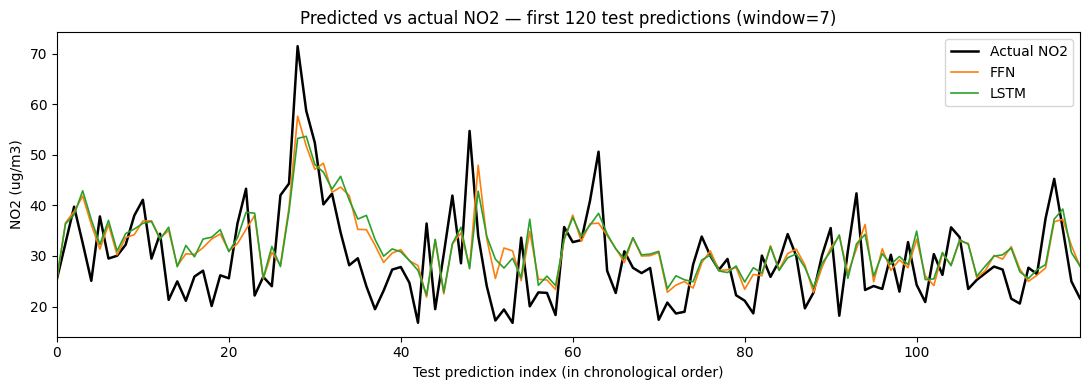

In [73]:
import matplotlib.pyplot as plt

n = 120  # number of test predictions to show
idx = range(n)

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(idx, yte_uni[:n],    label="Actual NO2", color="black",      lw=1.8)
ax.plot(idx, preds_ffn[:n],  label="FFN",        color="tab:orange", lw=1.2)
ax.plot(idx, preds_lstm[:n], label="LSTM",       color="tab:green",  lw=1.2)

ax.set_xlabel("Test prediction index (in chronological order)")
ax.set_ylabel("NO2 (ug/m3)")
ax.set_title("Predicted vs actual NO2 — first 120 test predictions (window=7)")
ax.set_xlim(0, n - 1)
ax.legend()
plt.tight_layout()
plt.show()

### Plot A interpretation
This plot shows our models' next-day forecasts against the real values. 
The models track normal fluctuations well, but they underestimate sudden pollution spikes — a known limitation of one-step forecasting. 
The FFN and LSTM produce nearly identical predictions, consistent with their similar error scores.

### Plot B — MAE vs window length (the FFN–LSTM crossover)

This plots the test MAE of each model against the input window length (7, 14, 30,
60 days), using the results from the window-length experiment. It shows the key
finding visually: the FFN gets worse as the window grows, while the LSTM stays
stable, so the LSTM overtakes the FFN at longer windows.

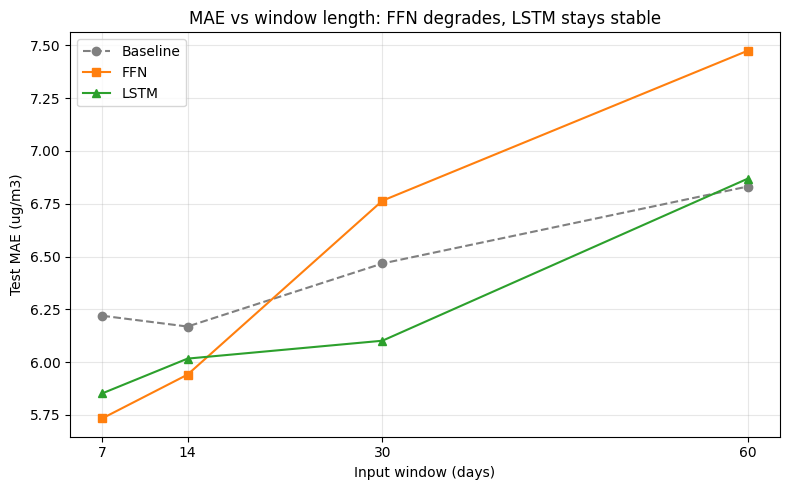

In [77]:
import matplotlib.pyplot as plt

# pull the numbers straight from the experiment dataframe (exp_df)
wins = exp_df["window"]

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(wins, exp_df["Pers_MAE"], "o--", label="Baseline", color="grey")
ax.plot(wins, exp_df["FFN_MAE"],  "s-",  label="FFN",         color="tab:orange")
ax.plot(wins, exp_df["LSTM_MAE"], "^-",  label="LSTM",        color="tab:green")

ax.set_xlabel("Input window (days)")
ax.set_ylabel("Test MAE (ug/m3)")
ax.set_title("MAE vs window length: FFN degrades, LSTM stays stable")
ax.set_xticks(wins)
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Plot b interpretation

With a short window the simple FFN is best, but as you feed in more past days the FFN falls 
apart while the LSTM stays steady — so the LSTM becomes the better choice for longer windows.

This shows why the model choice depends on the window size. With a short 7-day window the simpler FFN performs best. But as the window grows, the FFN's error rises sharply while the LSTM stays stable and overtakes it. This confirms the LSTM's advantage only appears when there's enough history for its sequence-modeling to matter.

### Plot C — Summary of all models (MAE and RMSE)

A single bar chart comparing every model at window 7: the persistence baseline,
FFN and LSTM (univariate), and FFN and LSTM (multivariate, with PM10). Shows MAE
and RMSE side by side. Lower bars = better. The dashed line marks the baseline
so it is easy to see which models beat it.

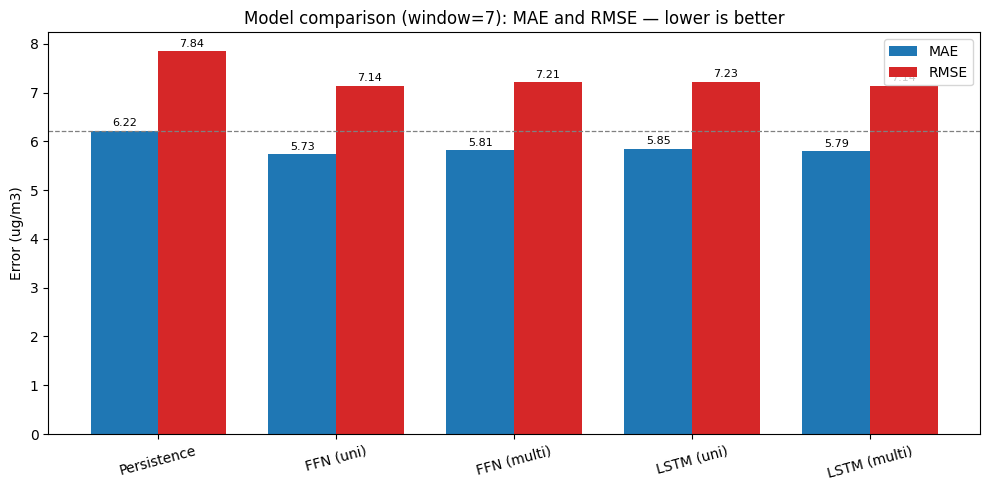

In [89]:
import matplotlib.pyplot as plt
import numpy as np

# order the models for the chart
names = ["Persistence", "FFN (uni)", "FFN (multi)", "LSTM (uni)", "LSTM (multi)"]
mae_vals  = [results[n]["MAE"]  for n in names]
rmse_vals = [results[n]["RMSE"] for n in names]

x = np.arange(len(names))
width = 0.38

fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(x - width/2, mae_vals,  width, label="MAE",  color="tab:blue")
bars2 = ax.bar(x + width/2, rmse_vals, width, label="RMSE", color="tab:red")

# dashed line at the baseline MAE for easy reference
ax.axhline(results["Persistence"]["MAE"], color="grey", ls="--", lw=0.9)

# put value labels on top of each bar
for b in list(bars1) + list(bars2):
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.05,
            f"{b.get_height():.2f}", ha="center", va="bottom", fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(names, rotation=15)
ax.set_ylabel("Error (ug/m3)")
ax.set_title("Model comparison (window=7): MAE and RMSE — lower is better")
ax.legend()
plt.tight_layout()
plt.show()

### Plot c interpretation
### What the model comparison shows

This chart compares all five models at a 7-day window using both error metrics
(MAE in blue, RMSE in red). Lower bars are better, and the dashed line marks the
persistence baseline's MAE.

Two things stand out. First, all four neural models beat the persistence
baseline — every blue bar sits below the dashed line — which confirms they
learned real structure in the data rather than just copying yesterday's value.
Second, the four neural models are almost identical to each other (MAE between
5.73 and 5.85). At this short window, it barely matters whether we use an FFN or
an LSTM, or whether we add PM10 as a second input.

RMSE is higher than MAE for every model, which is expected: RMSE penalises large
errors more heavily, and the models tend to make their biggest errors on sudden
pollution spikes.

This "all tied" picture at window 7 is exactly what motivated the window-length
experiment. That follow-up showed the models are only tied at short windows —
their real differences appear once the input window grows.

## Conclusions

The goal of this project was to forecast next-day NO2 concentration at a Cologne
traffic station (DENW212) and to compare models and input features in a
controlled way.

**Main findings:**

1. **All neural models beat the naive baseline.** Both the FFN and the LSTM
   outperformed persistence ("tomorrow = today"), reducing MAE from 6.22 to about
   5.7-5.9 ug/m3. The models learned genuine structure, though the improvement is
   modest because daily NO2 is highly autocorrelated, making persistence a strong
   baseline.

2. **Model choice depends on the input window.** At a short 7-day window the
   simpler FFN was marginally best. But as the window grew (30, 60 days) the FFN
   degraded sharply while the LSTM stayed stable and overtook it. The LSTM's
   sequence-modelling advantage only materialises when the input carries enough
   temporal structure.

3. **Adding PM10 gave little benefit.** The feature ablation largely falsified our
   hypothesis: PM10 consistently harmed the FFN and gave only a small, incons-
   istent improvement to the LSTM (clearest at a 14-day window). We attribute this
   to NO2's own history already carrying most of the predictive signal, and to
   ~37% of PM10 values being forward-filled, which weakened the feature.

4. **The models miss sudden spikes.** The predicted-vs-actual plots show the
   models track everyday NO2 well but underestimate sharp peaks — a known
   limitation of one-step forecasting.

**Overall:** a univariate model with a short window is a sound, simple default for
this task. The LSTM only justifies its added complexity with longer windows, and
PM10 is not worth adding for a simple model. Importantly, the "poor" or negative
results (LSTM not winning at window 7, PM10 not helping) are well explained by the
strong autocorrelation of NO2 and the quality of the PM10 data, which is exactly
the kind of reasoning this project set out to practise.

**Limitations and future work:** longer windows sharply reduce the usable sample
count (down to 27 test points at window 60), so those results are suggestive
rather than conclusive. Future work could use a station with better PM10 coverage
(avoiding heavy forward-filling), add weather variables (wind, temperature) as
inputs, or extend to a multi-station spatial model across NRW's 68 stations.